In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
print(torch.__version__)

2.9.0+cu126


IMAGE LOADING

In [2]:
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
import torchvision.transforms as transforms

In [3]:
from sklearn.model_selection import train_test_split

ROOT = Path("Dataset/bottle")

image_paths = sorted(
    (ROOT / "train" / "good").glob("*.png")
)

print("Total good images:", len(image_paths))

Total good images: 209


In [5]:
train_paths, val_paths = train_test_split(
    image_paths,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training images  :", len(train_paths))
print("Validation images:", len(val_paths))

Training images  : 167
Validation images: 42


In [6]:

ROOT = Path("Dataset/bottle")


train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    transforms.RandomRotation(degrees=10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),

    transforms.ToTensor()
])

In [17]:
class BottleTrainDataset(Dataset):

    def __init__(self, image_paths, transform=None, num_samples=None):
        self.image_paths = image_paths
        self.transform = transform
        self.num_samples = num_samples

    def __len__(self):
        if self.num_samples is None:
            return len(self.image_paths)
        return self.num_samples

    def __getitem__(self, idx):
        image_path = self.image_paths[idx % len(self.image_paths)]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

In [20]:
train_dataset = BottleTrainDataset(
    image_paths=train_paths,
    transform=train_transform,
    num_samples=10000
)

In [21]:

print("Number of training images:", len(train_dataset))
print("Image shape:", train_dataset[0].shape)
print ("Image tensor:", train_dataset[0])

Number of training images: 10000
Image shape: torch.Size([3, 256, 256])
Image tensor: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.]]])


In [22]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [23]:
images = next(iter(train_loader))
print(images.shape)

torch.Size([16, 3, 256, 256])


In [24]:
len(train_loader)

625

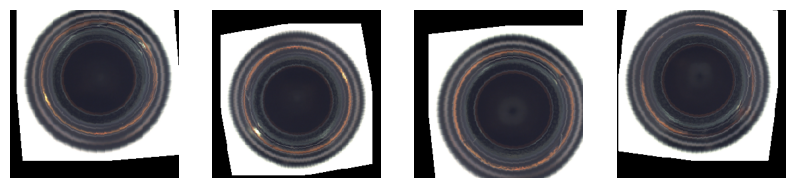

In [25]:
import matplotlib.pyplot as plt
images = next(iter(train_loader))
plt.figure(figsize=(10, 5))
for i in range(4):

    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.axis("off")

plt.show()

In [26]:
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [27]:
class BottleTestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.image_paths = []
        self.labels = []

        test_path = root / "test"
        for defect_folder in test_path.iterdir():
            if not defect_folder.is_dir():
                continue
            if defect_folder.name == "good":
                label = 0
            else:
                label = 1

            for image_path in defect_folder.glob("*.png"):
                self.image_paths.append(image_path)
                self.labels.append(label)
                print(f"Image path: {image_path}, Label: {label}")
        self.transform = transform
        print(transform)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image = Image.open(image_path).convert("RGB")
        label = self.labels[index]
        if self.transform:
            image = self.transform(image)

        return image, label

In [28]:
test_dataset = BottleTestDataset(
    ROOT,
    transform=test_transform
)

print("Number of test images:", len(test_dataset))

Image path: Dataset\bottle\test\broken_large\000.png, Label: 1
Image path: Dataset\bottle\test\broken_large\001.png, Label: 1
Image path: Dataset\bottle\test\broken_large\002.png, Label: 1
Image path: Dataset\bottle\test\broken_large\003.png, Label: 1
Image path: Dataset\bottle\test\broken_large\004.png, Label: 1
Image path: Dataset\bottle\test\broken_large\005.png, Label: 1
Image path: Dataset\bottle\test\broken_large\006.png, Label: 1
Image path: Dataset\bottle\test\broken_large\007.png, Label: 1
Image path: Dataset\bottle\test\broken_large\008.png, Label: 1
Image path: Dataset\bottle\test\broken_large\009.png, Label: 1
Image path: Dataset\bottle\test\broken_large\010.png, Label: 1
Image path: Dataset\bottle\test\broken_large\011.png, Label: 1
Image path: Dataset\bottle\test\broken_large\012.png, Label: 1
Image path: Dataset\bottle\test\broken_large\013.png, Label: 1
Image path: Dataset\bottle\test\broken_large\014.png, Label: 1
Image path: Dataset\bottle\test\broken_large\015.png, L

In [29]:
val_dataset = BottleTrainDataset(
    image_paths=val_paths,
    transform=test_transform,
    num_samples=None
)

In [30]:
BATCH_SIZE = 16

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [31]:
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [32]:
len(test_loader), len(val_loader)

(6, 3)

In [33]:
from collections import Counter
print(Counter(test_dataset.labels))

Counter({1: 63, 0: 20})


In [34]:
print(train_dataset[0])
print(len(train_dataset))
print(train_dataset[0].shape)

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.]]])
10000
torch.Size([3, 256, 256])


Model Building Script 

The important idea for anomaly detection is that the autoencoder is trained using the normal good bottle images. It learns to reconstruct the normal appearance. Later, when an anomalous bottle is given to it, the reconstruction error can be used as an anomaly signal. This is the basic reconstruction-based approach relevant to the MVTec setup

In [35]:
from torch import nn, optim

Conv AutoEncoder

In [47]:
import torch
import torch.nn as nn


class ConvAE(nn.Module):

    def __init__(self):
        super().__init__()

        # ENCODER
        # Input: 3 x 256 x 256

        self.encoder = nn.Sequential(

            # 3 x 256 x 256
            # Additional layer for 256x256 input
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 128 x 128
            nn.Conv2d(
                32, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.Conv2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.Conv2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.Conv2d(
                32, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 32 x 32
            nn.Conv2d(
                64, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 32 x 32
            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 16 x 16
            nn.Conv2d(
                128, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 16 x 16
            nn.Conv2d(
                64, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),
            #32 x 16 x 16
            nn.Conv2d(
                32, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 8 x 8
            # Latent representation
            nn.Conv2d(
                32, 128,
                kernel_size=8,
                stride=1,
                padding=0
            )

            # Output: 128 x 1 x 1
        )
        # DECODER

        self.decoder = nn.Sequential(

            # 128 x 1 x 1
            nn.ConvTranspose2d(
                128, 32,
                kernel_size=8,
                stride=1,
                padding=0
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(
                32, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),
            # 32 x 8 x 8
            nn.ConvTranspose2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),
            # 32 x 16 x 16
            nn.ConvTranspose2d(
                32, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 8 x 8
            nn.ConvTranspose2d(
                64, 128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 8 x 8
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 16 x 16
            nn.ConvTranspose2d(
                64, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 16 x 16
            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 32 x 32
            nn.ConvTranspose2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 32 x 32
            nn.ConvTranspose2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 32 x 32
            nn.ConvTranspose2d(
                32, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.ConvTranspose2d(
                32, 3,
                kernel_size=4,
                stride=2,
                padding=1
            )

            # Output: 3 x 256 x 256
        )


    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
x = torch.rand(3, 3).to(device)

Using device: cuda


In [38]:
torch.manual_seed(42)

In [39]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model = ConvAE().to(device)
print(model)

ConvAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): LeakyReLU(negative_slope=0.2, inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): LeakyReLU(negative_slope=0.2, inplace=True)
    (12): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): LeakyReLU(negative_slope=0.2, inplace=True)
    (14): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), paddin

In [40]:
x = torch.randn(4, 3, 256, 256).to(device)

with torch.no_grad():
    encoded = model.encoder(x)
    decoded = model.decoder(encoded)

print("Input:", x.shape)
print("Encoded:", encoded.shape)
print("Decoded:", decoded.shape)

Input: torch.Size([4, 3, 256, 256])
Encoded: torch.Size([4, 128, 1, 1])
Decoded: torch.Size([4, 3, 256, 256])


In [41]:
from torch.nn import MSELoss
loss_fn = MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0002
)

In [42]:
print(next(model.parameters()).device)

cuda:0


In [43]:
images = next(iter(train_loader))
print(images.device)
images = images.to(device)
print(images.device)

cpu
cuda:0


In [45]:
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

print("Model device:", next(model.parameters()).device)

images = next(iter(train_loader))
images = images.to(device)

print("Input device:", images.device)

CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU count: 1
Model device: cuda:0
Input device: cuda:0


In [49]:
EPOCHS=20
train_losses = []
for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0

    for images in train_loader:
        images = images.to(device)
        reconstructed = model(images)
        loss = loss_fn(reconstructed, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(
    f"Epoch [{epoch + 1}/{EPOCHS}], "
    f"Loss: {epoch_loss:.6f}"
)

Epoch [1/20], Loss: 0.078954
Epoch [2/20], Loss: 0.018805
Epoch [3/20], Loss: 0.011296
Epoch [4/20], Loss: 0.008849
Epoch [5/20], Loss: 0.007775
Epoch [6/20], Loss: 0.007146
Epoch [7/20], Loss: 0.006473
Epoch [8/20], Loss: 0.006457
Epoch [9/20], Loss: 0.006190
Epoch [10/20], Loss: 0.005747
Epoch [11/20], Loss: 0.005616
Epoch [12/20], Loss: 0.005433
Epoch [13/20], Loss: 0.005306
Epoch [14/20], Loss: 0.005061
Epoch [15/20], Loss: 0.004983
Epoch [16/20], Loss: 0.004772
Epoch [17/20], Loss: 0.004775
Epoch [18/20], Loss: 0.004487
Epoch [19/20], Loss: 0.004320
Epoch [20/20], Loss: 0.004282


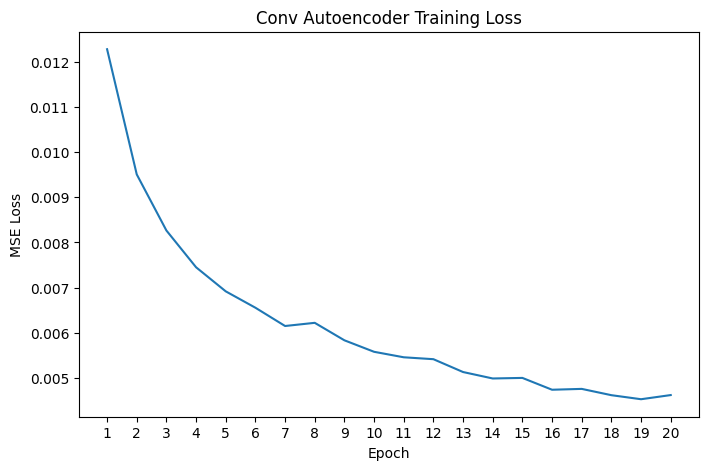

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, EPOCHS + 1), train_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Conv Autoencoder Training Loss")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

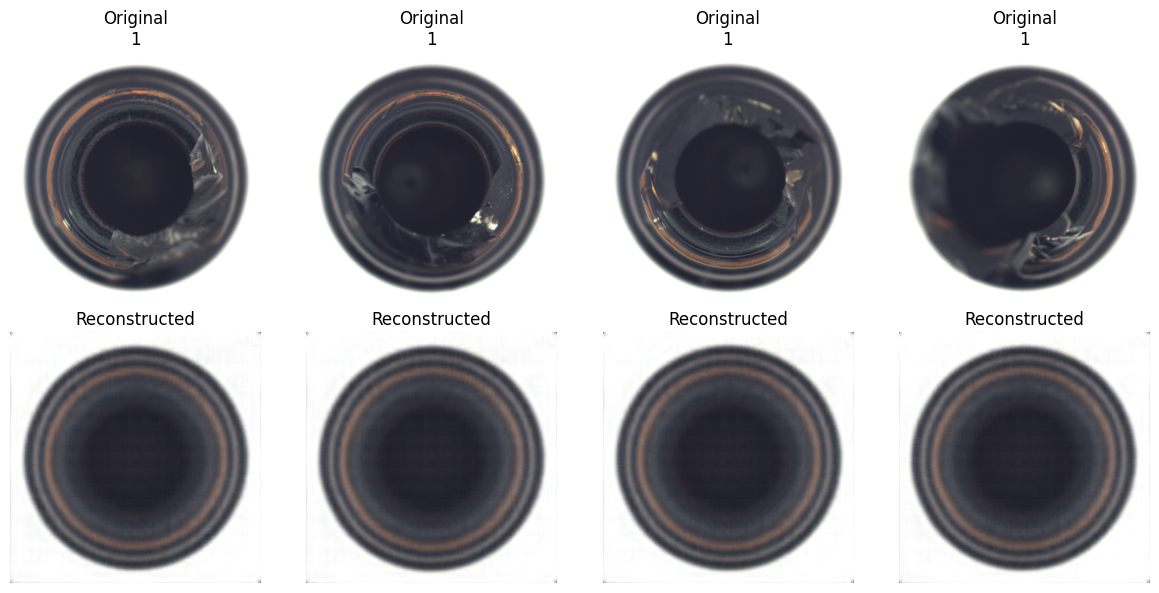

In [53]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed = model(images)

fig = plt.figure(figsize=(12, 6))

for i in range(4):

    # Original
    plt.subplot(2, 4, i + 1)
    plt.imshow(
        images[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title(f"Original\n{labels[i].item()}")
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 4, i + 5)
    plt.imshow(
        reconstructed[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [54]:
model.eval()

val_errors = []

with torch.no_grad():

    for images in val_loader:

        images = images.to(device)

        reconstructed = model(images)

        errors = torch.mean(
            (images - reconstructed) ** 2,
            dim=(1, 2, 3)
        )

        val_errors.extend(errors.cpu().numpy())

In [55]:
print(val_errors[0])
print(val_errors[0].shape)
print(len(val_errors))
print(val_errors[:10])

0.0019996003
()
42
[np.float32(0.0019996003), np.float32(0.0021115455), np.float32(0.0020984674), np.float32(0.0019794572), np.float32(0.0026295087), np.float32(0.0019441536), np.float32(0.002055344), np.float32(0.0019420547), np.float32(0.0018280906), np.float32(0.0025514434)]


In [56]:
import numpy as np

val_errors = np.array(val_errors)
mean_err = np.mean(val_errors)
std_err = np.std(val_errors)

print("Number of validation images:", len(val_errors))
print("Mean error:", mean_err)
print("Std error:", std_err)
print("Max error:", val_errors.max())

Number of validation images: 42
Mean error: 0.0021516823
Std error: 0.00032023774
Max error: 0.0030211322


In [57]:
threshold = np.percentile(val_errors, 99)
print("Threshold:", threshold)

Threshold: 0.00295772


In [58]:
'''for p in [95, 97, 98, 99, 99.5]:
    t = np.percentile(val_errors, p)
    print(f"{p}% threshold: {t:.6f}")'''

'for p in [95, 97, 98, 99, 99.5]:\n    t = np.percentile(val_errors, p)\n    print(f"{p}% threshold: {t:.6f}")'

In [59]:

threshold_2std = mean_err + 2 * std_err
threshold_3std = mean_err + 3 * std_err

print(f"Validation error stats:")
print(f"  Mean: {mean_err:.6f}")
print(f"  Std:  {std_err:.6f}")
print(f"  Threshold (mean + 2*std): {threshold_2std:.6f}")
print(f"  Threshold (mean + 3*std): {threshold_3std:.6f}")
print("Threshold 99 percentile:", threshold)

Validation error stats:
  Mean: 0.002152
  Std:  0.000320
  Threshold (mean + 2*std): 0.002792
  Threshold (mean + 3*std): 0.003112
Threshold 99 percentile: 0.00295772


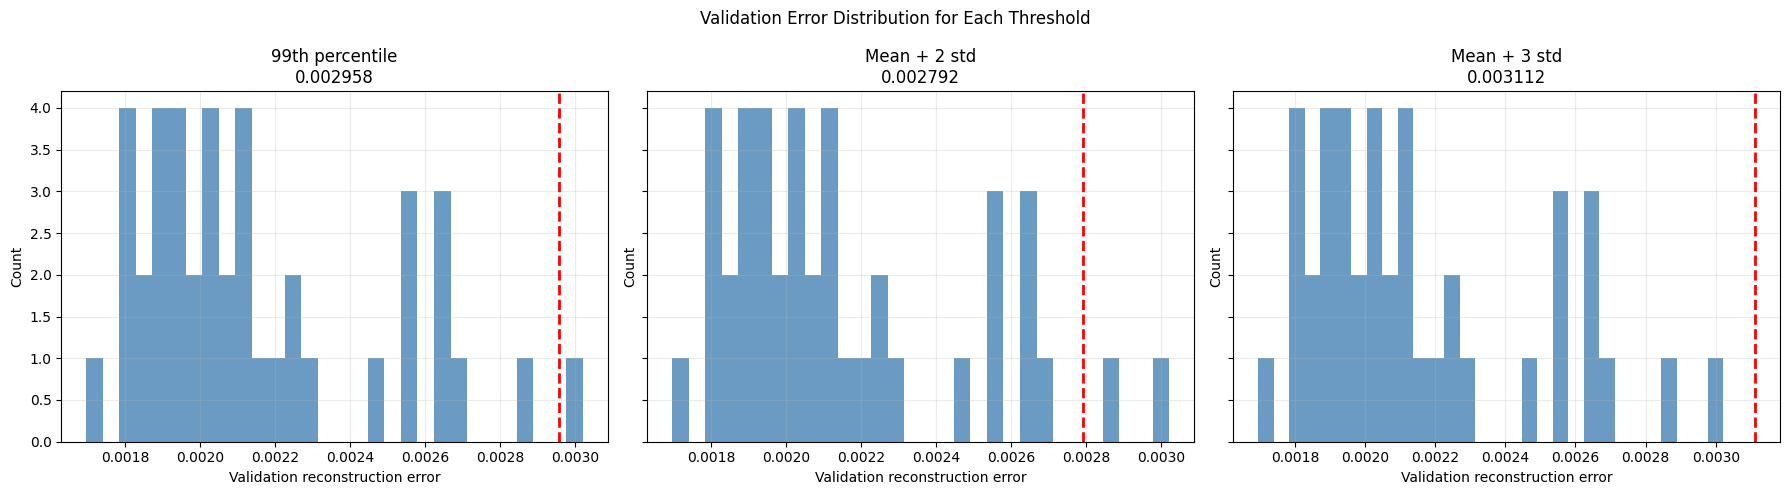

In [60]:
val_errors = np.asarray(val_errors)
mean_err = np.mean(val_errors)
std_err = np.std(val_errors)

thresholds = {
    "99th percentile": np.percentile(val_errors, 99),
    "Mean + 2 std": mean_err + 2 * std_err,
    "Mean + 3 std": mean_err + 3 * std_err,
}

fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 5), sharey=True)

for axis, (name, value) in zip(axes, thresholds.items()):
    axis.hist(val_errors, bins=30, color="steelblue", alpha=0.8)
    axis.axvline(value, color="red", linestyle="--", linewidth=2)
    axis.set_title(f"{name}\n{value:.6f}")
    axis.set_xlabel("Validation reconstruction error")
    axis.set_ylabel("Count")
    axis.grid(alpha=0.25)

fig.suptitle("Validation Error Distribution for Each Threshold")
fig.tight_layout()
plt.show()

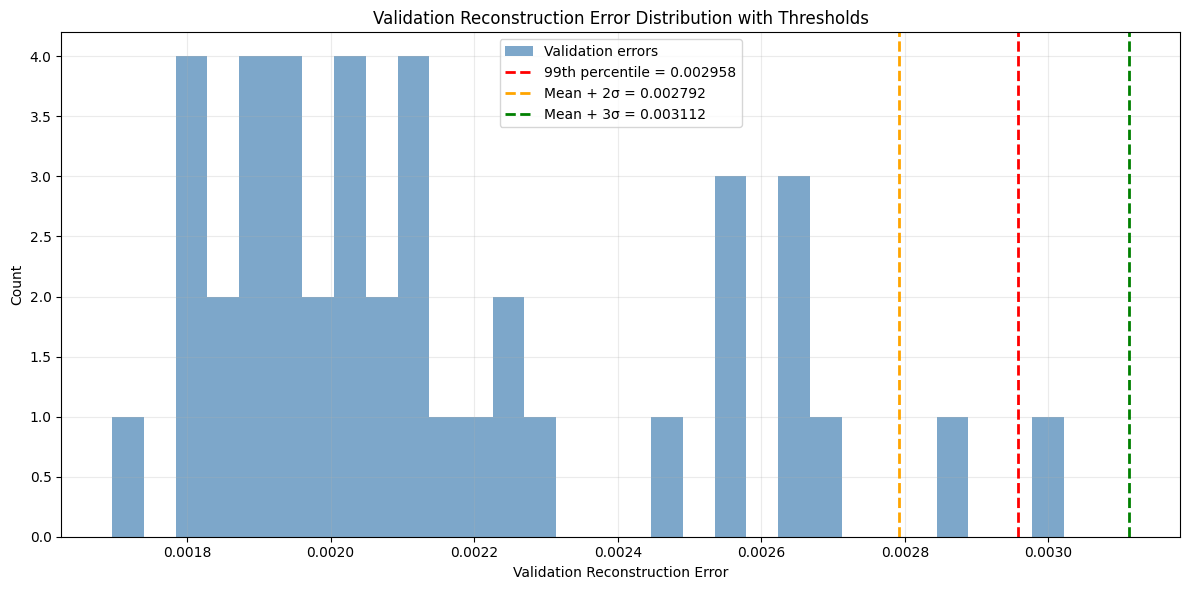

In [ ]:
val_errors = np.asarray(val_errors)

mean_err = np.mean(val_errors)
std_err = np.std(val_errors)

thresholds = {
    "99th percentile": np.percentile(val_errors, 99),
    "Mean + 2 std": mean_err + 2 * std_err,
    "Mean + 3 std": mean_err + 3 * std_err,
}

plt.figure(figsize=(12, 6))
plt.hist(
    val_errors,
    bins=30,
    alpha=0.7,
    color="steelblue",
    label="Validation errors"
)

plt.axvline(
    thresholds["99th percentile"],
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"99th percentile = {thresholds['99th percentile']:.6f}"
)

plt.axvline(
    thresholds["Mean + 2 std"],
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Mean + 2σ = {thresholds['Mean + 2 std']:.6f}"
)

plt.axvline(
    thresholds["Mean + 3 std"],
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Mean + 3σ = {thresholds['Mean + 3 std']:.6f}"
)

plt.xlabel("Validation Reconstruction Error")
plt.ylabel("Count")
plt.title("Validation Reconstruction Error Distribution with Thresholds")

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [66]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_size": [3, 256, 256],
    "thresholds": {
        name: float(value)
        for name, value in thresholds.items()
    },
    "selected_threshold": float(thresholds["99th percentile"]),
    "validation_mean_error": float(mean_err),
    "validation_std_error": float(std_err),
}

torch.save(checkpoint, "conv_autoencoder_validation.pth")
print("Saved model checkpoint: conv_autoencoder_validation.pth")
print("Selected validation threshold:", checkpoint["selected_threshold"])

Saved model checkpoint: conv_autoencoder_validation.pth
Selected validation threshold: 0.0029577200766652822


In [61]:
model.eval()

test_errors = []
test_labels = []

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        reconstructed = model(images)
        errors = torch.mean(
            (images - reconstructed) ** 2,
            dim=(1, 2, 3)
        )
        test_errors.extend(errors.cpu().numpy())
        test_labels.extend(labels.numpy())

In [62]:
test_errors = np.array(test_errors)
test_labels = np.array(test_labels)

predictions = (test_errors >= threshold).astype(int)

In [63]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(test_labels, predictions)

print("Threshold:", threshold)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, predictions))

print("\nClassification Report:")
print(classification_report(test_labels, predictions))

Threshold: 0.00295772
Accuracy: 0.6385542168674698

Confusion Matrix:
[[20  0]
 [30 33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      1.00      0.57        20
           1       1.00      0.52      0.69        63

    accuracy                           0.64        83
   macro avg       0.70      0.76      0.63        83
weighted avg       0.86      0.64      0.66        83

